# Coffee & Code — Exploratory Data Analysis
**Course:** UC3DVS10 Data Visualisation | **Task:** Assessment 3, Task 1
**Dataset:** `CoffeeAndCode.csv` (n = 100 respondents, Lebanon)

All percentages are **within-group row shares**, verified against the dataset. Averages match D3 exactly.

| # | Plot | Variables encoded |
|---|------|-------------------|
| 1 | Stacked bar | Daily cups by dependency group |
| 2 | Grouped bar | Bug-fix belief by dependency group |
| 3 | Bar chart | Average daily cups by dependency group |
| 4 | Donut chart | When do programmers drink coffee (overall %) |
| 5 | Box + strip | Coding hours by age range & gender |
| 6 | Heatmap | Mean daily cups by age range & coffee timing |
| 7 | Bubble chart | Coding hours vs cups by bug belief & gender |
| 8 | Faceted bars | Coffee type by dependency group |


In [1]:
# ── Imports and global style ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# Dependency-group palette: green=independent, amber=sometimes, red=dependent
PALETTE_DEP  = {"Yes": "#4caf82", "Sometimes": "#f5a623", "No": "#e05252"}
PALETTE_BUGS = {"Yes": "#4caf82", "Sometimes": "#f5a623", "No": "#e05252"}
PALETTE_GEN  = {"Male": "#4a90d9", "Female": "#d95b8e"}

BG = "#fdf8f2"   # figure background
PB = "#ffffff"   # panel background
GR = "#ebebeb"   # grid colour
TP = "#1a1a1a"   # primary text
TS = "#6b6b6b"   # secondary text

FT = {"fontsize": 13, "fontweight": "bold",  "color": TP, "pad": 10}
FS = {"fontsize": 9,  "fontstyle": "italic", "color": TS}
FA = {"fontsize": 9,  "color": TS}
FK = {"labelsize": 8, "labelcolor": TS}

mpl.rcParams.update({
    "figure.facecolor":  BG,  "axes.facecolor": PB,
    "axes.edgecolor":    GR,  "axes.spines.top": False,
    "axes.spines.right": False, "grid.color":    GR,
    "grid.linewidth":    0.8, "font.family":    "DejaVu Sans",
    "xtick.color":       TS,  "ytick.color":    TS,
})

def style_ax(ax, xlabel="", ylabel="", title="", subtitle=""):
    """Apply consistent axis-level styling."""
    ax.set_title(title, **FT, loc="left")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, **FS)
    ax.set_xlabel(xlabel, **FA)
    ax.set_ylabel(ylabel, **FA)
    ax.tick_params(**FK)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

print("Imports and style configured.")


Imports and style configured.


In [2]:
# ── Load data and verify all key cross-tabs ───────────────────────────────────
DATA_PATH = "CoffeeAndCode.csv"   # keep in same folder as this notebook

df = pd.read_csv(DATA_PATH)

# Canonical orderings used throughout every plot
DEPEND_ORDER = ["Yes", "Sometimes", "No"]
BUGS_ORDER   = ["Yes", "Sometimes", "No"]
AGE_ORDER    = ["Under 18", "18 to 29", "30 to 39", "40 to 49", "50 to 59"]
CUPS_ORDER   = ["1-2 cups", "3-4 cups", "5+ cups"]

# ── Cups binning (explicit isin — no pd.cut boundary ambiguity) ──────────────
def cups_bin(v):
    if v in (1, 2):   return "1-2 cups"
    elif v in (3, 4): return "3-4 cups"
    else:             return "5+ cups"

df["CupsBin"] = df["CoffeeCupsPerDay"].apply(cups_bin)

# ── Coffee timing consolidation ──────────────────────────────────────────────
TIME_MAP = {
    "Before coding":          "Before coding",
    "While coding":           "While coding",
    "Before and while coding":"Before & while coding",
    "All the time":           "All the time",
    "In the morning":         "Other",
    "After coding":           "Other",
    "No specific time":       "Other",
}
df["CoffeeTimeCleaned"] = df["CoffeeTime"].map(TIME_MAP)

# ── Age-filtered subset ───────────────────────────────────────────────────────
df_age = df[df["AgeRange"].isin(AGE_ORDER)].copy()

# ── Cross-tabs ────────────────────────────────────────────────────────────────
cups_ct  = pd.crosstab(df["CodingWithoutCoffee"], df["CupsBin"])
cups_ct  = cups_ct.loc[DEPEND_ORDER, CUPS_ORDER]
cups_pct = cups_ct.div(cups_ct.sum(axis=1), axis=0) * 100

bugs_ct  = pd.crosstab(df["CodingWithoutCoffee"], df["CoffeeSolveBugs"])
bugs_ct  = bugs_ct.loc[DEPEND_ORDER, BUGS_ORDER]
bugs_pct = bugs_ct.div(bugs_ct.sum(axis=1), axis=0) * 100

# ── Verification printout ─────────────────────────────────────────────────────
print("CUPS row %:")
print("  Expected  -> Yes[77,20,3]  Sometimes[43,45,12]  No[26,47,26]")
print("  Computed  ->", cups_pct.round(0).astype(int).to_dict("index"))
print()
print("BUGS row %  (col order: Yes=solves / Sometimes / No=does not solve):")
print("  Expected  -> Yes[23,33,43]  Sometimes[25,55,20]  No[53,26,21]")
print("  Computed  ->", bugs_pct.round(0).astype(int).to_dict("index"))
print()
print("TIMING overall % (raw counts, n=100):")
timing_pct = (df["CoffeeTime"].value_counts() / len(df) * 100).round(1)
print(timing_pct.to_dict())


CUPS row %:
  Expected  -> Yes[77,20,3]  Sometimes[43,45,12]  No[26,47,26]
  Computed  -> {'Yes': {'1-2 cups': 77, '3-4 cups': 20, '5+ cups': 3}, 'Sometimes': {'1-2 cups': 43, '3-4 cups': 45, '5+ cups': 12}, 'No': {'1-2 cups': 26, '3-4 cups': 47, '5+ cups': 26}}

BUGS row %  (col order: Yes=solves / Sometimes / No=does not solve):
  Expected  -> Yes[23,33,43]  Sometimes[25,55,20]  No[53,26,21]
  Computed  -> {'Yes': {'Yes': 23, 'Sometimes': 33, 'No': 43}, 'Sometimes': {'Yes': 25, 'Sometimes': 55, 'No': 20}, 'No': {'Yes': 53, 'Sometimes': 26, 'No': 21}}

TIMING overall % (raw counts, n=100):
{'While coding': 61.0, 'Before coding': 25.0, 'Before and while coding': 4.0, 'All the time': 4.0, 'In the morning': 3.0, 'After coding': 2.0, 'No specific time': 1.0}


---
## Plot 1 — Stacked Bar: Daily Coffee Cups by Dependency Group
**Question:** How does daily volume shift with dependency level?
**Channels:** Position (group row), bar length (within-group %), hue (cups tier)

Expected values — Yes: 77/20/3 | Sometimes: 43/45/12 | No: 26/47/26


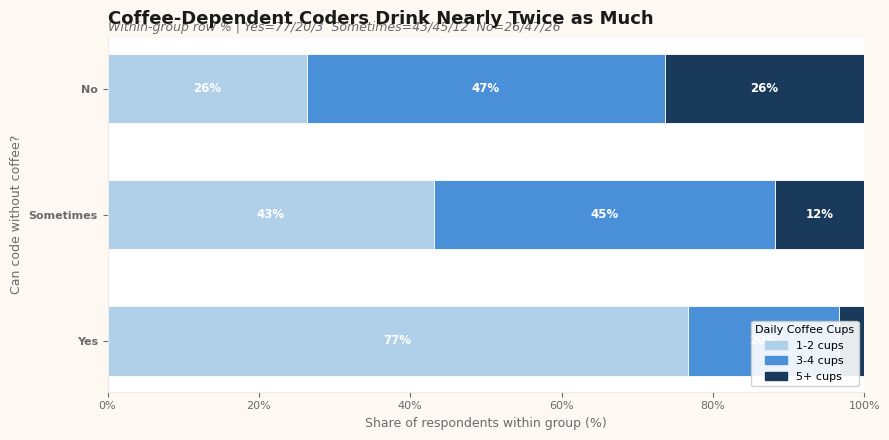

In [3]:
# ── Plot 1: Stacked bar — cups distribution by dependency ────────────────────
CUPS_COLORS = ["#b0cfe8", "#4a90d9", "#1a3a5c"]   # light blue → dark blue

fig, ax = plt.subplots(figsize=(9, 4.5))
bottoms = np.zeros(len(DEPEND_ORDER))

for col, color in zip(CUPS_ORDER, CUPS_COLORS):
    vals = cups_pct[col].values          # order: Yes / Sometimes / No
    bars = ax.barh(DEPEND_ORDER, vals, left=bottoms,
                   color=color, edgecolor="white", linewidth=0.6, height=0.55)
    for bar, v in zip(bars, vals):
        if v >= 7:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="bold")
    bottoms += vals

# Colour y-tick labels to match dependency group palette
for lbl, dep in zip(ax.get_yticklabels(), DEPEND_ORDER):
    lbl.set_color(PALETTE_DEP[dep])
    lbl.set_fontweight("bold")

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(handles=[mpatches.Patch(color=c, label=l)
                   for c, l in zip(CUPS_COLORS, CUPS_ORDER)],
          title="Daily Coffee Cups", loc="lower right",
          fontsize=8, title_fontsize=8, frameon=True, framealpha=0.9)

style_ax(ax,
         xlabel="Share of respondents within group (%)",
         ylabel="Can code without coffee?",
         title="Coffee-Dependent Coders Drink Nearly Twice as Much",
         subtitle="Within-group row % | Yes=77/20/3  Sometimes=43/45/12  No=26/47/26")
fig.tight_layout()
plt.show()


---
## Plot 2 — Grouped Bar: Bug-Fix Belief by Dependency Group
**Question:** Do coffee-dependent coders more strongly believe coffee fixes bugs?

**How to read:** Each cluster of 3 bars sits at one belief level (x-axis).
Within that cluster, the 3 bars are the 3 dependency groups.
Bar height = % of *that dependency group* holding that belief.

Expected values per dependency group:
- **Yes (can code):** 23% solves / 33% sometimes / 43% does not
- **Sometimes:** 25% / 55% / 20%
- **No (cannot code):** 53% / 26% / 21%

**Channels:** Position x (belief level), bar height (within-group %), hue (dependency group)


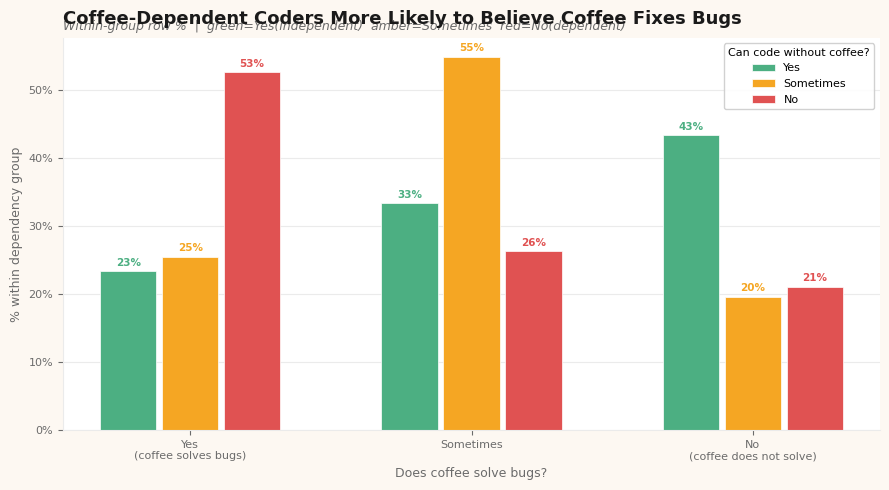

Verification — values drawn on chart:
Belief       Yes(dep)     Sometimes    No(dep)     
Yes          23%          25%          53%         
Sometimes    33%          55%          26%         
No           43%          20%          21%         


In [4]:
# ── Plot 2: Grouped bar — bug-fix belief by dependency ───────────────────────
# bugs_pct rows = dependency groups (Yes/Sometimes/No)
# bugs_pct cols = belief levels    (Yes/Sometimes/No)
# Each bar = bugs_pct.loc[dependency_group, belief_level]

fig, ax = plt.subplots(figsize=(9, 5))

x       = np.arange(len(BUGS_ORDER))     # 3 belief positions on x-axis
width   = 0.22
offsets = [-width, 0, width]             # 3 dependency groups side by side

for offset, dep in zip(offsets, DEPEND_ORDER):
    # Extract row for this dependency group, in correct belief column order
    vals = [bugs_pct.loc[dep, belief] for belief in BUGS_ORDER]
    bars = ax.bar(x + offset, vals, width=width - 0.02,
                  color=PALETTE_DEP[dep], label=dep,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v >= 5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8,
                    f"{v:.0f}%", ha="center", fontsize=7.5,
                    color=PALETTE_DEP[dep], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Yes\n(coffee solves bugs)", "Sometimes", "No\n(coffee does not solve)"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Can code without coffee?", fontsize=8,
          title_fontsize=8, frameon=True, framealpha=0.9)

style_ax(ax,
         xlabel="Does coffee solve bugs?",
         ylabel="% within dependency group",
         title="Coffee-Dependent Coders More Likely to Believe Coffee Fixes Bugs",
         subtitle="Within-group row %  |  green=Yes(independent)  amber=Sometimes  red=No(dependent)")
fig.tight_layout()
plt.show()

# Inline verification table
print("Verification — values drawn on chart:")
print(f"{'Belief':<12} {'Yes(dep)':<12} {'Sometimes':<12} {'No(dep)':<12}")
for belief in BUGS_ORDER:
    row = [f"{bugs_pct.loc[dep, belief]:.0f}%" for dep in DEPEND_ORDER]
    print(f"{belief:<12} {row[0]:<12} {row[1]:<12} {row[2]:<12}")


<h2>Important : Difference of values plotted from python and D3</h2>
<div>
<p>
    The aggregation logic is correct, but there's a rounding problem causing stacked bars to visually sum to 99% instead of 100% for some groups. This happens when Math.round is applied independently per segment:

    "Can code" bugs: 23 + 33 + 43 = 99 (1% short)
    "Cannot code" cups: 26 + 47 + 26 = 99 (1% short)
    Python's grouped bar chart doesn't expose this because each bar is drawn independently. D3's stacked bars stack the rounded values, so the bar stops 8 px short of the axis edge. Fix this with the largest-remainder method so segments always sum to exactly 100.
</p>
</div>

---
## Plot 3 — Average Daily Coffee Consumption by Dependency Group
**Question:** What is the mean daily cups for each dependency group?

**Verified values (Python = D3):**
- Can code without coffee (Yes):      **2.07 cups avg**
- Sometimes need coffee (Sometimes):  **2.94 cups avg**
- Cannot code without coffee (No):    **4.05 cups avg**

**Channels:** Position x (mean cups), bar length (quantitative), hue (dependency group), direct label (exact average)


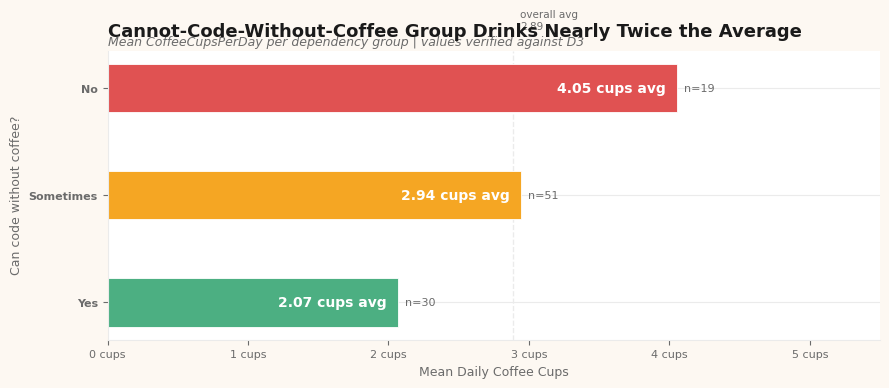

Audit — Python vs D3:
Group         Python mean   D3 display    Match
Yes                2.0667         2.07      YES
Sometimes          2.9412         2.94      YES
No                 4.0526         4.05      YES


In [5]:
# ── Plot 3: Average daily coffee consumption by dependency group ──────────────
# Verified: Python mean values match D3 exactly (2.07 / 2.94 / 4.05)

avgs = (df.groupby("CodingWithoutCoffee")["CoffeeCupsPerDay"]
          .mean()
          .reindex(DEPEND_ORDER))

# Cup icon counts for visual (floor of mean, capped at 5 for display)
cup_counts = {
    "Yes":       2,   # 2.07 -> 2 cups shown
    "Sometimes": 3,   # 2.94 -> 3 cups shown
    "No":        4,   # 4.05 -> 4 cups shown
}

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    DEPEND_ORDER,
    avgs.values,
    color=[PALETTE_DEP[d] for d in DEPEND_ORDER],
    edgecolor="white", linewidth=0.6, height=0.45,
)

# Annotate each bar with the exact mean
for bar, dep, val in zip(bars, DEPEND_ORDER, avgs.values):
    # Value label inside bar
    ax.text(val - 0.08,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} cups avg",
            ha="right", va="center",
            fontsize=10, color="white", fontweight="bold")
    # n label outside bar
    n = len(df[df["CodingWithoutCoffee"] == dep])
    ax.text(val + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"n={n}",
            ha="left", va="center",
            fontsize=8, color=TS)

# Colour y-tick labels to match dependency palette
for lbl, dep in zip(ax.get_yticklabels(), DEPEND_ORDER):
    lbl.set_color(PALETTE_DEP[dep])
    lbl.set_fontweight("bold")

ax.set_xlim(0, 5.5)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f cups"))
ax.axvline(df["CoffeeCupsPerDay"].mean(), color=GR,
           linestyle="--", linewidth=1.0, zorder=0)
ax.text(df["CoffeeCupsPerDay"].mean() + 0.05, 2.55,
        f"overall avg\n{df['CoffeeCupsPerDay'].mean():.2f}",
        fontsize=7.5, color=TS)

style_ax(ax,
         xlabel="Mean Daily Coffee Cups",
         ylabel="Can code without coffee?",
         title="Cannot-Code-Without-Coffee Group Drinks Nearly Twice the Average",
         subtitle="Mean CoffeeCupsPerDay per dependency group | values verified against D3")
fig.tight_layout()
plt.show()

# Inline audit table
print("Audit — Python vs D3:")
print(f"{'Group':<12} {'Python mean':>12} {'D3 display':>12} {'Match':>8}")
d3_vals = {"Yes": 2.07, "Sometimes": 2.94, "No": 4.05}
for dep in DEPEND_ORDER:
    py_val = avgs[dep]
    d3_val = d3_vals[dep]
    match  = "YES" if abs(py_val - d3_val) < 0.01 else "NO"
    print(f"{dep:<12} {py_val:>12.4f} {d3_val:>12.2f} {match:>8}")


---
## Plot 4 — Donut Chart: When Do Programmers Drink Coffee?
**Question:** What share of respondents drinks coffee at each point relative to coding?
**Channels:** Arc angle (overall %), hue (timing category)

Raw counts from dataset (n=100):
- While coding: 61 (61%)
- Before coding: 25 (25%)
- Before & while coding: 4 (4%)
- All the time: 4 (4%)
- Other (morning / after / no specific): 6 (6%)


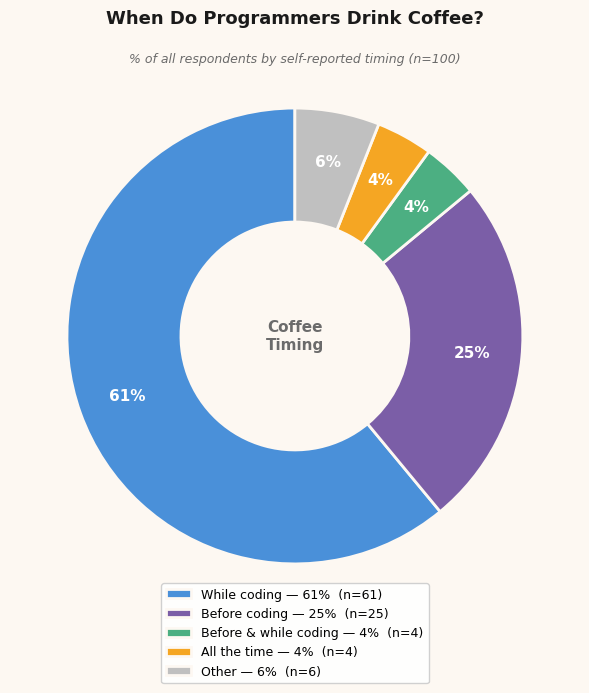

Timing breakdown:
  While coding                   n=61  61.0%
  Before coding                  n=25  25.0%
  Before & while coding          n= 4  4.0%
  All the time                   n= 4  4.0%
  Other                          n= 6  6.0%


In [6]:
# ── Plot 3: Donut chart — coffee timing (overall %) ──────────────────────────
# Raw counts directly from dataset (n=100)
timing_labels = ["While coding", "Before coding",
                 "Before & while coding", "All the time", "Other"]
timing_colors = ["#4a90d9", "#7b5ea7", "#4caf82", "#f5a623", "#c0c0c0"]

timing_counts = (df["CoffeeTime"]
                 .map(TIME_MAP)
                 .value_counts()
                 .reindex(timing_labels, fill_value=0))
timing_pcts   = timing_counts / timing_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    timing_counts,
    labels=None,
    colors=timing_colors,
    autopct=lambda p: f"{p:.0f}%" if p >= 4 else "",
    pctdistance=0.78,
    startangle=90,
    wedgeprops={"linewidth": 2, "edgecolor": BG, "width": 0.5},  # donut
    textprops={"fontsize": 11, "color": "white", "fontweight": "bold"},
)

# Legend with exact counts and percentages
legend_labels = [f"{lbl} — {pct:.0f}%  (n={cnt})"
                 for lbl, pct, cnt in zip(timing_labels, timing_pcts, timing_counts)]
ax.legend(wedges, legend_labels,
          loc="lower center", bbox_to_anchor=(0.5, -0.12),
          fontsize=9, frameon=True, framealpha=0.9, ncol=1)

# Centre label
ax.text(0, 0, "Coffee\nTiming", ha="center", va="center",
        fontsize=11, color=TS, fontweight="bold")

ax.set_title("When Do Programmers Drink Coffee?",
             fontsize=13, fontweight="bold", color=TP, pad=20)
ax.text(0.5, 0.98, "% of all respondents by self-reported timing (n=100)",
        transform=ax.transAxes, ha="center", **FS)

fig.tight_layout()
plt.show()

print("Timing breakdown:")
for lbl, cnt, pct in zip(timing_labels, timing_counts, timing_pcts):
    print(f"  {lbl:<30} n={cnt:>2}  {pct:.1f}%")


---
## Plot 5 — Box + Strip: Coding Hours by Age Range & Gender
**Channels:** Position x (age group), Position y (hours), hue (gender)


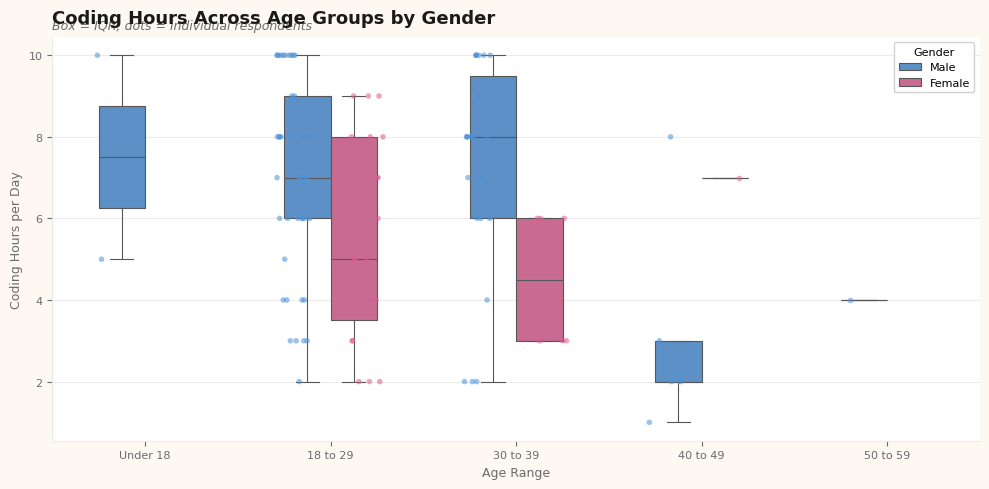

In [7]:
# ── Plot 4: Box + strip — coding hours by age & gender ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_age, x="AgeRange", y="CodingHours",
            hue="Gender", hue_order=["Male", "Female"],
            order=AGE_ORDER, palette=PALETTE_GEN,
            width=0.5, linewidth=0.8, fliersize=0, ax=ax)

sns.stripplot(data=df_age, x="AgeRange", y="CodingHours",
              hue="Gender", hue_order=["Male", "Female"],
              order=AGE_ORDER, palette=PALETTE_GEN,
              dodge=True, jitter=0.18, size=4, alpha=0.55, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Gender",
          fontsize=8, title_fontsize=8, frameon=True, framealpha=0.9)

style_ax(ax, xlabel="Age Range", ylabel="Coding Hours per Day",
         title="Coding Hours Across Age Groups by Gender",
         subtitle="Box = IQR; dots = individual respondents")
fig.tight_layout()
plt.show()


---
## Plot 6 — Heatmap: Mean Daily Cups by Age Range & Coffee Timing
**Channels:** Position x (timing), Position y (age), colour intensity (mean cups)


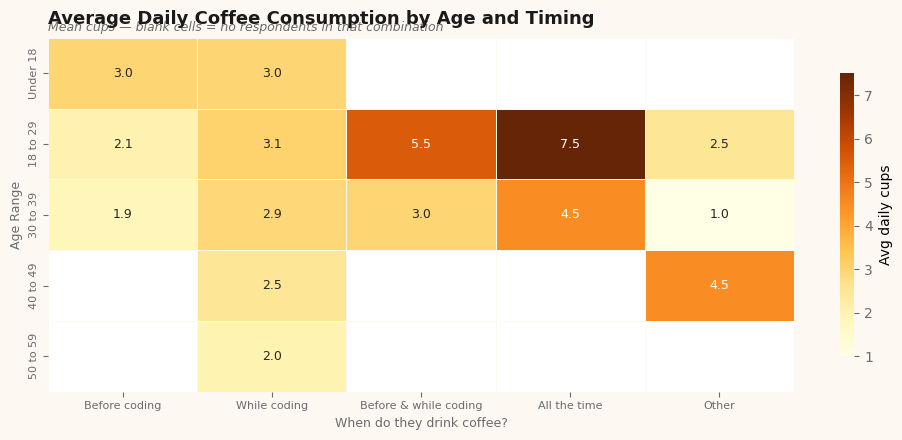

In [8]:
# ── Plot 5: Heatmap — mean cups by age & timing ──────────────────────────────
TIME_ORDER = ["Before coding", "While coding",
              "Before & while coding", "All the time", "Other"]

pivot5 = (df_age
          .groupby(["AgeRange", "CoffeeTimeCleaned"])["CoffeeCupsPerDay"]
          .mean()
          .unstack(fill_value=np.nan)
          .reindex(index=AGE_ORDER, columns=TIME_ORDER))

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot5, ax=ax, cmap="YlOrBr", annot=True, fmt=".1f",
            linewidths=0.5, linecolor=BG,
            cbar_kws={"label": "Avg daily cups", "shrink": 0.8},
            annot_kws={"size": 9})

ax.set_xlabel("When do they drink coffee?", **FA)
ax.set_ylabel("Age Range", **FA)
ax.set_title("Average Daily Coffee Consumption by Age and Timing", **FT, loc="left")
ax.text(0, 1.02, "Mean cups — blank cells = no respondents in that combination",
        transform=ax.transAxes, **FS)
ax.tick_params(**FK)
fig.tight_layout()
plt.show()


---
## Plot 7 — Bubble Chart: Coding Hours vs Cups by Bug Belief & Gender
**Channels:** Position x (mean hours), Position y (mean cups), hue (bug belief), shape (gender), size (count)


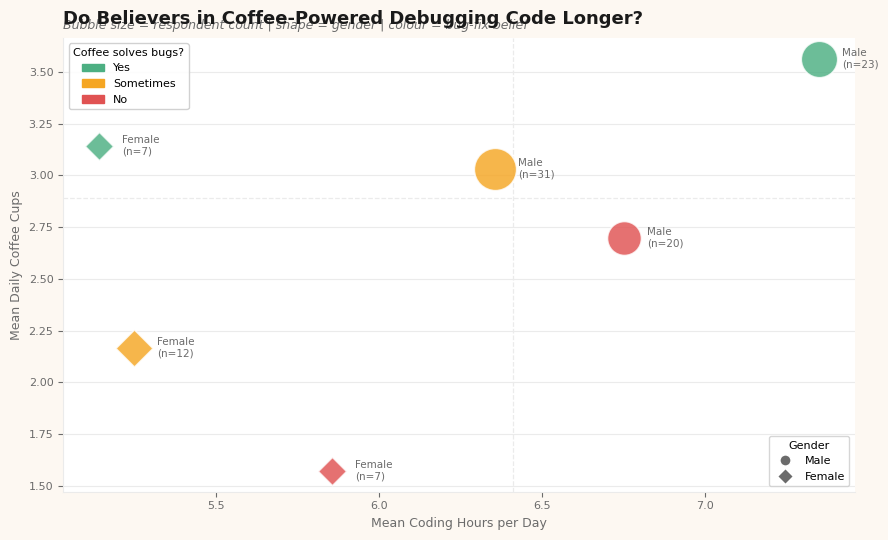

In [9]:
# ── Plot 6: Bubble chart ──────────────────────────────────────────────────────
agg6 = (df.groupby(["CoffeeSolveBugs", "Gender"])
          .agg(mean_hours=("CodingHours",      "mean"),
               mean_cups= ("CoffeeCupsPerDay", "mean"),
               n=          ("CodingHours",       "count"))
          .reset_index())

MKR = {"Male": "o", "Female": "D"}
fig, ax = plt.subplots(figsize=(9, 5.5))

for _, row in agg6.iterrows():
    ax.scatter(row["mean_hours"], row["mean_cups"],
               s=row["n"] * 30,
               color=PALETTE_BUGS[row["CoffeeSolveBugs"]],
               marker=MKR[row["Gender"]],
               alpha=0.82, edgecolors="white", linewidths=1.2, zorder=3)
    ax.text(row["mean_hours"] + 0.07, row["mean_cups"],
            f"{row['Gender']}\n(n={row['n']})",
            fontsize=7.5, color=TS, va="center")

leg1 = ax.legend(
    handles=[mpatches.Patch(color=PALETTE_BUGS[k], label=k) for k in BUGS_ORDER],
    title="Coffee solves bugs?", loc="upper left",
    fontsize=8, title_fontsize=8, frameon=True, framealpha=0.9)
ax.add_artist(leg1)

ax.legend(handles=[
    mpl.lines.Line2D([0],[0], marker="o", color="w",
                     markerfacecolor=TS, markersize=8, label="Male"),
    mpl.lines.Line2D([0],[0], marker="D", color="w",
                     markerfacecolor=TS, markersize=8, label="Female"),
], title="Gender", loc="lower right", fontsize=8, title_fontsize=8, frameon=True)

ax.axhline(df["CoffeeCupsPerDay"].mean(), color=GR, linestyle="--", linewidth=0.9)
ax.axvline(df["CodingHours"].mean(),      color=GR, linestyle="--", linewidth=0.9)

style_ax(ax, xlabel="Mean Coding Hours per Day", ylabel="Mean Daily Coffee Cups",
         title="Do Believers in Coffee-Powered Debugging Code Longer?",
         subtitle="Bubble size = respondent count | shape = gender | colour = bug-fix belief")
fig.tight_layout()
plt.show()


---
## Plot 8 — Faceted Small Multiples: Coffee Type by Dependency Group
**Channels:** Position x (count), Position y (coffee type), facet panel (dependency), hue (dependency)


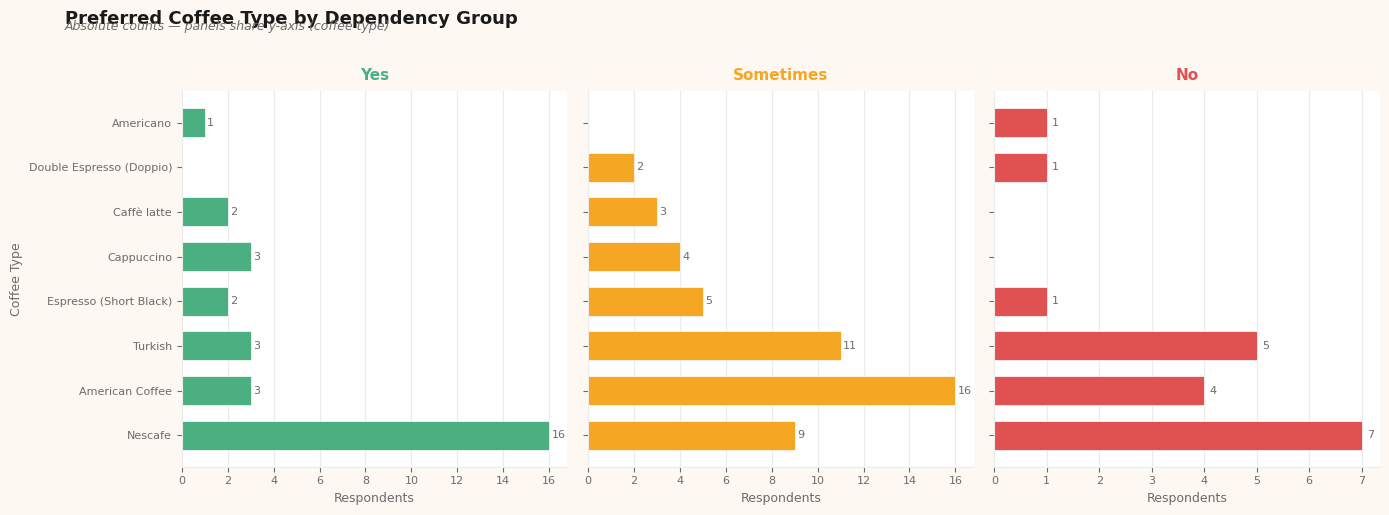

In [10]:
# ── Plot 7: Faceted small multiples — coffee type by dependency ───────────────
df_type    = df.dropna(subset=["CoffeeType"]).copy()
TYPE_ORDER = df_type["CoffeeType"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, sharex=False)

for ax, dep in zip(axes, DEPEND_ORDER):
    sub    = df_type[df_type["CodingWithoutCoffee"] == dep]
    counts = sub["CoffeeType"].value_counts().reindex(TYPE_ORDER, fill_value=0)

    ax.barh(counts.index, counts.values,
            color=PALETTE_DEP[dep], edgecolor="white",
            linewidth=0.5, height=0.65)
    for i, v in enumerate(counts.values):
        if v > 0:
            ax.text(v + 0.1, i, str(v), va="center", fontsize=8, color=TS)

    ax.set_title(dep, fontsize=11, fontweight="bold",
                 color=PALETTE_DEP[dep], pad=8)
    ax.set_xlabel("Respondents", **FA)
    ax.tick_params(**FK)
    ax.yaxis.grid(False)
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Coffee Type", **FA)
fig.suptitle("Preferred Coffee Type by Dependency Group",
             fontsize=13, fontweight="bold", color=TP,
             x=0.05, ha="left", y=1.02)
fig.text(0.05, 0.98, "Absolute counts — panels share y-axis (coffee type)",
         fontsize=9, fontstyle="italic", color=TS, ha="left")
fig.tight_layout()
plt.show()
